# QCNN Benchmark: Ansatz and Encoding Matrix Study
**4-class Fashion-MNIST (T-shirt, Trouser, Sneaker, Bag); 16×16; 4 ansatz × 3 encoding × 3 seeds = 36 runs.**

## 1. Environment Setup

Install all required packages. Analysis (Sections 6-7) runs on CPU; GPU is only needed for training (Section 5).

In [1]:
# Install all required packages (re-run if any import fails).
%pip install -q pennylane==0.45.0 pennylane-lightning==0.45.0 \
              torch torchvision \
              numpy pandas matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, sys, json, glob, warnings, math as _math, random, csv, time
from pathlib import Path

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.datasets as _tvds
import torchvision.transforms as _tvtf
from torch.utils.data import DataLoader as _DL, Dataset as _DS, Subset as _Sub

# Quantum computing
import pennylane as qml

warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 11})
sns.set_palette("Set2")
COLORS = sns.color_palette("Set2", 8)

ROOT    = Path.cwd()
RESULTS = ROOT / "results_qcnn"

CLASS_NAMES  = ["T-shirt", "Trouser", "Sneaker", "Bag"]
ANSATZ_ORDER = ["hur6", "hur8", "hur9", "custom_ansatz"]
ENC_ORDER    = ["e3", "e1", "custom"]
ANSATZ_COLORS = {a: COLORS[i] for i, a in enumerate(ANSATZ_ORDER)}

print(f"Results directory : {RESULTS}")
if RESULTS.exists():
    completed = [d for d in RESULTS.iterdir()
                 if d.is_dir() and (d / "test.json").exists()]
    print(f"Completed runs    : {len(completed)}")
else:
    print("Results directory not found. Expected results_qcnn/ at repository root.")

Results directory : c:\Users\ferdi\Documents\Github\SEAI_project_BRUTTO\results_qcnn
Completed runs    : 36


## 2. Dataset Overview

| Label | Class | Train | Val | Test |
|-------|-------|------:|----:|-----:|
| 0 | T-shirt/top | 3 000 | 500 | 500 |
| 1 | Trouser | 3 000 | 500 | 500 |
| 7 | Sneaker | 3 000 | 500 | 500 |
| 8 | Bag | 3 000 | 500 | 500 |

Images are down-sampled from 28 × 28 to **16 × 16** and normalised to [0, 1].
Random-chance accuracy for the balanced 4-class problem is **25 %**.

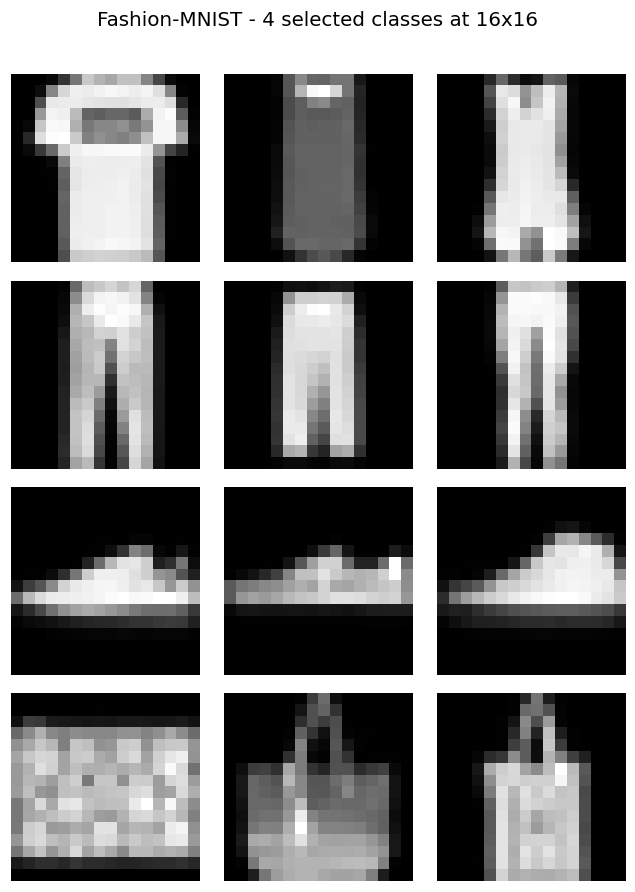

In [3]:
import torch, torchvision
import torchvision.transforms as T

_ds = torchvision.datasets.FashionMNIST(
    root=str(ROOT / ".cache" / "fmnist"), train=True, download=True,
    transform=T.Compose([T.Resize(16), T.ToTensor()]))

TARGET = {0: "T-shirt", 1: "Trouser", 7: "Sneaker", 8: "Bag"}
samples = {k: [] for k in TARGET}
for img, lbl in _ds:
    if lbl in samples and len(samples[lbl]) < 3:
        samples[lbl].append(img.squeeze().numpy())
    if all(len(v) == 3 for v in samples.values()):
        break

fig, axes = plt.subplots(4, 3, figsize=(6, 8))
for row, lbl in enumerate(TARGET):
    for col in range(3):
        ax = axes[row, col]
        ax.imshow(samples[lbl][col], cmap="gray", interpolation="nearest")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(TARGET[lbl], fontsize=12, rotation=90, va="center")
fig.suptitle("Fashion-MNIST - 4 selected classes at 16x16", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 3. Model Architecture

### 3.1 Ansatz Circuits

| Ansatz | Type | Params | Gate structure |
|--------|------|:------:|----------------|
| `hur6` | SO(4) | 6 | RY-RY - CNOT - RY-RY - CNOT - RY-RY |
| `hur8` | Hur baseline | 10 | RX-RX - RZ-RZ - RX-RX - CNOT - RX-RX - RZ-RZ |
| `hur9` | SU(4)/KAK | 15 | U3-U3 - CNOT - RY-RZ - CNOT - RY - CNOT - U3-U3 |
| `custom` | Cartan | 11 | RZ-RY (×2) - IsingXX/YY/ZZ - RY-RZ (×2) |

Conv layer: same parameter vector shared across all qubit pairs (translational invariance).
Pooling: `hur_pool_pair` (CRZ + open-CRX, **2 params**) for `hur6` / `hur8`;
`transfer_pooling_pair` (CNOT-CRY-CRZ-RY, **3 params**) for `custom_ansatz`.
`hur9` uses **trace-out pooling** (no learnable pool parameters) per the "9b" variant.

### 3.2 Encoding Strategies

| Encoding | Qubits | Extra params | Description |
|----------|:------:|:------------:|-------------|
| `e3` | 8 | 0 | `AmplitudeEmbedding`: maps 256 normalised pixel amplitudes to the statevector |
| `e1` | 9 | 16 | Affine angle encoding on 8 qubits + global ancilla (wire 8); re-uploads 4 global statistics via CNOT-RZ-CNOT fusion |
| `custom` | 8 | 96 | Pairwise fragment re-uploading: 4 image patches × 4 re-upload steps × 4 learned affine-mapped features |

### 3.3 Total Trainable Parameters

| Ansatz | n_conv | n_pool | +e3 (0) | +e1 (16) | +custom (96) |
|--------|:------:|:------:|:-------:|:--------:|:------------:|
| `hur6` | 6 | 2 | 16 | 32 | 112 |
| `hur8` | 10 | 2 | 24 | 40 | 120 |
| `hur9` | 15 | **0** | **30** | **46** | **126** |
| `custom` | 11 | 3 | **39** | **55** | **135** |

### 3.4 Training Setup

| Hyperparameter | Value |
|----------------|-------|
| Optimiser | AdamW |
| LR | 1e-3 |
| Scheduler | Cosine annealing warm restarts (T₀ = EPOCHS // 3) |
| Batch size | 24 |
| Max epochs | 20 |
| Label smoothing | 0.1 |
| Gradient clipping | norm 1.0 |
| **Early stopping criterion** | **val_acc** (patience = 10, min Δ = 0.001 absolute) |
| **Best checkpoint** | **epoch with highest val_acc** |

Early stopping and best-checkpoint selection use **validation accuracy** (not val_loss) to avoid the label-smoothing pathology where val_loss can decrease while accuracy degrades.

In [4]:
import pennylane as qml

# -- Ansatz circuits (inlined) ------------------------------------------------

def hur6(theta, wires):
    """SO(4) circuit, 6 parameters."""
    a, b = wires
    qml.RY(theta[0], wires=a); qml.RY(theta[1], wires=b)
    qml.CNOT(wires=[a, b])
    qml.RY(theta[2], wires=a); qml.RY(theta[3], wires=b)
    qml.CNOT(wires=[a, b])
    qml.RY(theta[4], wires=a); qml.RY(theta[5], wires=b)

def hur8(theta, wires):
    """Hur 2022 baseline circuit, 10 parameters."""
    a, b = wires
    qml.RX(theta[0], wires=a); qml.RX(theta[1], wires=b)
    qml.RZ(theta[2], wires=a); qml.RZ(theta[3], wires=b)
    qml.RX(theta[4], wires=a); qml.RX(theta[5], wires=b)
    qml.CNOT(wires=[a, b])
    qml.RX(theta[6], wires=a); qml.RX(theta[7], wires=b)
    qml.RZ(theta[8], wires=a); qml.RZ(theta[9], wires=b)

def hur9(theta, wires):
    """SU(4) / KAK circuit, 15 parameters."""
    a, b = wires
    qml.U3(theta[0], theta[1], theta[2], wires=a)
    qml.U3(theta[3], theta[4], theta[5], wires=b)
    qml.CNOT(wires=[a, b])
    qml.RY(theta[6], wires=a); qml.RZ(theta[7], wires=b)
    qml.CNOT(wires=[b, a]); qml.RY(theta[8], wires=a)
    qml.CNOT(wires=[a, b])
    qml.U3(theta[9],  theta[10], theta[11], wires=a)
    qml.U3(theta[12], theta[13], theta[14], wires=b)

def custom_ansatz(theta, wires):
    """Cartan-inspired circuit, 11 parameters."""
    a, b = wires
    qml.RZ(theta[0], wires=a); qml.RY(theta[1], wires=a)
    qml.RZ(theta[2], wires=b); qml.RY(theta[3], wires=b)
    qml.IsingXX(theta[4], wires=[a, b])
    qml.IsingYY(theta[5], wires=[a, b])
    qml.IsingZZ(theta[6], wires=[a, b])
    qml.RY(theta[7], wires=a); qml.RZ(theta[8], wires=a)
    qml.RY(theta[9], wires=b); qml.RZ(theta[10], wires=b)

def conv_layer(conv_fn, theta, active_wires):
    """Translationally invariant conv: even + shifted pairs, shared params."""
    n = len(active_wires)
    even    = [(active_wires[i], active_wires[i+1]) for i in range(0, n-1, 2)]
    shifted = [(active_wires[i], active_wires[i+1]) for i in range(1, n-1, 2)]
    for pair in even + shifted:
        conv_fn(theta, pair)

print("Ansatz circuits defined.")

Ansatz circuits defined.


## 4. Training Library

All code needed to reproduce the 36-run benchmark from scratch.
Run cells 4a-4d once before using the CLI in Section 5.
If only using the pre-computed results, skip directly to Section 6.

In [6]:
# 4a -- Imports and hyperparameters ----------------------------------------
import math as _math, random, csv, os, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as _tvds
import torchvision.transforms as _tvtf
import pennylane as qml
from torch.utils.data import DataLoader as _DL, Dataset as _DS, Subset as _Sub

IMG_SIZE        = 16
N_CLASSES       = 4
CLASS_MAP       = {0: 0, 1: 1, 7: 2, 8: 3}
TRAIN_PER_CLASS = 3000
VAL_PER_CLASS   = 500
TEST_PER_CLASS  = 500
BATCH_SIZE      = 24
EPOCHS_DEFAULT  = 20
LR_QKERNEL      = 1e-3
LR_EMBED        = 1e-3
WD_QKERNEL      = 0.0
WD_EMBED        = 0.0
LABEL_SMOOTHING          = 0.1
EARLY_STOP_PATIENCE      = 10
EARLY_STOP_MIN_ACC_DELTA = 0.001
E1_INIT_A      = 0.2
LAMBDA_FUSION  = _math.pi / 4
E1_OMEGA_FIXED = _math.pi / 2
BETA_GLOBAL    = (1.0, 10.0, 10.0, 1.0)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


print('4a: config ready.')

4a: config ready.


In [7]:
# 4b -- Data loading (4-class Fashion-MNIST, 16x16) -------------------------
_fmnist_tf = _tvtf.Compose([_tvtf.Resize((IMG_SIZE, IMG_SIZE)), _tvtf.ToTensor()])


def _quad_means_8(x):
    img = x.squeeze(0)
    return torch.stack([img[r*8:(r+1)*8, c*4:(c+1)*4].mean()
                        for r in range(2) for c in range(4)])


def _ga4(x):
    img = x.squeeze(0)
    gx  = img[:, 1:] - img[:, :-1]
    gy  = img[1:, :] - img[:-1, :]
    hv  = img.var(dim=1, unbiased=False).mean()
    vv  = img.var(dim=0, unbiased=False).mean()
    return torch.stack([
        img.mean() - 0.5,
        img.var(unbiased=False),
        (gx.pow(2).mean() + gy.pow(2).mean()) / 2,
        (hv - vv) / (hv + vv + 1e-8),
    ])


class _FashionDS(_DS):
    def __init__(self, subset, class_map):
        self.subset = subset
        self.class_map = class_map

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        return x.reshape(-1), _quad_means_8(x), _ga4(x), self.class_map[int(y)]


def _balanced_idx(ds, class_map, n, offset=0, seed=42):
    buckets = {c: [] for c in class_map}
    for i in range(len(ds)):
        y = int(ds[i][1])
        if y in buckets:
            buckets[y].append(i)
    sel = []
    rng = np.random.default_rng(seed)
    for c in class_map:
        arr = np.array(buckets[c])
        rng.shuffle(arr)
        if offset + n > len(arr):
            raise ValueError(f'Not enough samples for class {c}')
        sel.extend(arr[offset:offset + n].tolist())
    rng.shuffle(sel)
    return sel


def load_data(seed=42, batch_size=BATCH_SIZE, train_per_class=TRAIN_PER_CLASS):
    cache = str(ROOT / '.cache' / 'fmnist')
    trn = _tvds.FashionMNIST(root=cache, train=True,  download=True, transform=_fmnist_tf)
    tst = _tvds.FashionMNIST(root=cache, train=False, download=True, transform=_fmnist_tf)
    ti = _balanced_idx(trn, CLASS_MAP, train_per_class, 0, seed)
    vi = _balanced_idx(trn, CLASS_MAP, VAL_PER_CLASS,   train_per_class, seed)
    ei = _balanced_idx(tst, CLASS_MAP, TEST_PER_CLASS,  0, seed)
    trl = _DL(_FashionDS(_Sub(trn, ti), CLASS_MAP), batch_size=batch_size, shuffle=True)
    vll = _DL(_FashionDS(_Sub(trn, vi), CLASS_MAP), batch_size=batch_size, shuffle=False)
    tel = _DL(_FashionDS(_Sub(tst, ei), CLASS_MAP), batch_size=batch_size, shuffle=False)
    return trl, vll, tel


print('4b: data loading ready.')

4b: data loading ready.


In [8]:
# 4c -- Encodings, pooling, and FashionQCNN model ---------------------------
import math as _mc


# --- Encoding helpers -------------------------------------------------------
def _compute_gamma(gA4):
    beta = gA4.new_tensor(list(BETA_GLOBAL))
    return _mc.pi * torch.tanh(beta * gA4)


def _enc_e3(x_flat, n_q=8):
    qml.AmplitudeEmbedding(features=x_flat, wires=range(n_q), normalize=True)


def _enc_e1(qm8, g4, a, c, anc=8):
    for i in range(8):
        qml.RY(a[i] * (_mc.pi * qm8[:, i]) + c[i], wires=i)
    for fn, col in [(qml.RY, 0), (qml.RZ, 1), (qml.RX, 2), (qml.RZ, 3)]:
        fn(g4[:, col], wires=anc)
    qml.RY(E1_OMEGA_FIXED, wires=anc)
    for fn, col in [(qml.RZ, 0), (qml.RX, 1), (qml.RY, 2), (qml.RZ, 3)]:
        fn(g4[:, col], wires=anc)
    for i in range(8):
        qml.CNOT(wires=[anc, i])
        qml.RZ(LAMBDA_FUSION, wires=i)
        qml.CNOT(wires=[anc, i])


def _enc_custom(patches, theta_enc):
    def _pair(patch, grp, ws):
        a, b = ws
        for s in range(4):
            base = 4 * s
            z = [grp[s, k] * patch[:, base + j] + grp[s, k + 1]
                 for j, k in enumerate([0, 2, 4, 6])]
            qml.RY(z[0], wires=a); qml.RZ(z[1], wires=a)
            qml.RX(z[2], wires=b); qml.RY(z[3], wires=b)
            qml.CNOT(wires=[a, b])
            qml.RY(grp[s, 8], wires=a); qml.RZ(grp[s, 9], wires=b)
            qml.CNOT(wires=[b, a])
            qml.RX(grp[s, 10], wires=a); qml.RY(grp[s, 11], wires=b)
    for pi, ws in enumerate([(0, 1), (2, 3), (4, 5), (6, 7)]):
        _pair(patches[:, pi, :], theta_enc[0 if pi < 2 else 1], ws)


# --- Pooling ----------------------------------------------------------------
def _pool_hur(tp, ctrl, tgt):
    qml.CRZ(tp[0], wires=[ctrl, tgt])
    qml.PauliX(wires=ctrl); qml.CRX(tp[1], wires=[ctrl, tgt]); qml.PauliX(wires=ctrl)


def _pool_transfer(tp, disc, keep):
    qml.CNOT(wires=[disc, keep])
    qml.CRY(tp[0], wires=[disc, keep]); qml.CRZ(tp[1], wires=[disc, keep])
    qml.RY(tp[2], wires=keep)


def _pool_layer(fn, tp, pairs):
    for d, k in pairs:
        fn(tp, d, k)


# --- Convolutional layer driver ---------------------------------------------
def _conv_layer(conv_fn, theta, wires):
    n = len(wires)
    even    = [(wires[i], wires[i + 1]) for i in range(0, n - 1, 2)]
    shifted = [(wires[i], wires[i + 1]) for i in range(1, n - 1, 2)]
    for pair in even + shifted:
        conv_fn(theta, pair)


# --- Custom encoding preprocessing ------------------------------------------
def _patches(x_flat):
    import math as _m
    B   = x_flat.shape[0]
    img = x_flat.reshape(B, 16, 16)

    def _block(p):
        return _m.pi * p.reshape(B, 4, 2, 4, 2).mean(dim=(2, 4)).reshape(B, -1)

    return torch.stack([
        _block(img[:, 0:8,  0:8]),  _block(img[:, 0:8,  8:16]),
        _block(img[:, 8:16, 0:8]),  _block(img[:, 8:16, 8:16]),
    ], dim=1)


# --- Ansatz registry --------------------------------------------------------
_W8 = [0, 1, 2, 3, 4, 5, 6, 7]; _W4 = [0, 2, 4, 6]; _OW = [0, 4]
_P1 = [(1, 0), (3, 2), (5, 4), (7, 6)]; _P2 = [(2, 0), (6, 4)]
_TRACE_POOL = {'hur9'}
_FINAL_CLS  = {'custom_ansatz'}
_AReg = {
    'hur6':          (hur6,          6,  _pool_hur,      2),
    'hur8':          (hur8,         10,  _pool_hur,      2),
    'hur9':          (hur9,         15,  _pool_hur,      2),
    'custom_ansatz': (custom_ansatz, 11, _pool_transfer, 3),
}


# --- FashionQCNN model ------------------------------------------------------
class FashionQCNN(nn.Module):
    def __init__(self, ansatz_name, encoding_name, init_scale=0.01):
        super().__init__()
        conv_fn, n_conv, pool_fn, n_pool = _AReg[ansatz_name]
        n_q = 9 if encoding_name == 'e1' else 8
        self.ansatz_name   = ansatz_name
        self.encoding_name = encoding_name
        self.conv_fn  = conv_fn; self.pool_fn = pool_fn; self.n_conv = n_conv
        self.use_pool = ansatz_name not in _TRACE_POOL
        self.use_fin  = ansatz_name in _FINAL_CLS
        self.n_pool   = n_pool if self.use_pool else 0

        self.theta_conv1 = nn.Parameter(init_scale * torch.randn(n_conv))
        self.theta_conv2 = nn.Parameter(init_scale * torch.randn(n_conv))
        if self.use_pool:
            self.theta_pool1 = nn.Parameter(init_scale * torch.randn(self.n_pool))
            self.theta_pool2 = nn.Parameter(init_scale * torch.randn(self.n_pool))
        else:
            self.register_buffer('theta_pool1', torch.empty(0))
            self.register_buffer('theta_pool2', torch.empty(0))
        self.theta_final = (
            nn.Parameter(init_scale * torch.randn(n_conv)) if self.use_fin else None
        )
        if encoding_name == 'e1':
            self.a_embed   = nn.Parameter(torch.full((8,), E1_INIT_A))
            self.c_embed   = nn.Parameter(torch.zeros(8))
            self.theta_enc = None
        elif encoding_name == 'custom':
            t = init_scale * torch.randn(2, 4, 12)
            t[:, :, [0, 2, 4, 6]] += 1.0
            self.theta_enc = nn.Parameter(t)
            self.a_embed   = self.c_embed = None
        else:
            self.a_embed = self.c_embed = self.theta_enc = None

        self.dev   = qml.device('default.qubit', wires=n_q)
        self.qnode = self._build_qnode()

    def _build_qnode(self):
        cfn = self.conv_fn; pfn = self.pool_fn; enc = self.encoding_name
        up = self.use_pool; uf = self.use_fin

        def _ap(tp, pairs):
            if up: _pool_layer(pfn, tp, pairs)

        def _af(tf):
            if uf: cfn(tf, _OW)

        if enc == 'e3':
            @qml.qnode(self.dev, interface='torch', diff_method='backprop')
            def _q(x, c1, p1, c2, p2, tf):
                _enc_e3(x)
                _conv_layer(cfn, c1, _W8); _ap(p1, _P1)
                _conv_layer(cfn, c2, _W4); _ap(p2, _P2); _af(tf)
                return qml.probs(wires=_OW)
            return _q
        elif enc == 'e1':
            @qml.qnode(self.dev, interface='torch', diff_method='backprop')
            def _q(qm8, g4, a, c, c1, p1, c2, p2, tf):
                _enc_e1(qm8, g4, a, c)
                _conv_layer(cfn, c1, _W8); _ap(p1, _P1)
                _conv_layer(cfn, c2, _W4); _ap(p2, _P2); _af(tf)
                return qml.probs(wires=_OW)
            return _q
        else:
            @qml.qnode(self.dev, interface='torch', diff_method='backprop')
            def _q(pts, te, c1, p1, c2, p2, tf):
                _enc_custom(pts, te)
                _conv_layer(cfn, c1, _W8); _ap(p1, _P1)
                _conv_layer(cfn, c2, _W4); _ap(p2, _P2); _af(tf)
                return qml.probs(wires=_OW)
            return _q

    def forward(self, x_flat, quad_means_8=None, gA4=None):
        emp = x_flat.new_empty(0)
        tf  = self.theta_final if self.theta_final is not None else emp
        if self.encoding_name == 'e3':
            return self.qnode(x_flat,
                              self.theta_conv1, self.theta_pool1,
                              self.theta_conv2, self.theta_pool2, tf).float()
        elif self.encoding_name == 'e1':
            return self.qnode(quad_means_8, _compute_gamma(gA4),
                              self.a_embed, self.c_embed,
                              self.theta_conv1, self.theta_pool1,
                              self.theta_conv2, self.theta_pool2, tf).float()
        else:
            return self.qnode(_patches(x_flat), self.theta_enc,
                              self.theta_conv1, self.theta_pool1,
                              self.theta_conv2, self.theta_pool2, tf).float()

    def n_trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


print('4c: model ready.')

4c: model ready.


In [9]:
# 4d -- Training loop and suite runner --------------------------------------


def _prob_xent(probs, y, eps=1e-8, label_smoothing=0.0):
    lp  = torch.log(torch.clamp(probs, eps, 1.0))
    nll = -lp[torch.arange(len(y), device=y.device), y]
    if label_smoothing > 0:
        return ((1 - label_smoothing) * nll - label_smoothing * lp.mean(dim=1)).mean()
    return nll.mean()


def _acc(probs, y):
    return (probs.argmax(1) == y).float().mean().item()


def _build_opt(model):
    qk = [p for name in ('theta_conv1', 'theta_pool1', 'theta_conv2',
                         'theta_pool2', 'theta_final')
          if (p := getattr(model, name, None)) is not None
          and isinstance(p, nn.Parameter) and p.requires_grad]
    groups = [{'params': qk, 'lr': LR_QKERNEL, 'weight_decay': WD_QKERNEL}]
    emb = [p for name in ('a_embed', 'c_embed', 'theta_enc')
           if (p := getattr(model, name, None)) is not None]
    if emb:
        groups.append({'params': emb, 'lr': LR_EMBED, 'weight_decay': WD_EMBED})
    return torch.optim.AdamW(groups)


def _confusion(model, loader, device):
    model.eval()
    cm = torch.zeros(N_CLASSES, N_CLASSES, dtype=torch.int64)
    with torch.no_grad():
        for xf, qm, ga, y in loader:
            pr = model(xf.to(device), quad_means_8=qm.to(device), gA4=ga.to(device))
            for t, p in zip(y, pr.argmax(1).cpu()):
                cm[int(t), int(p)] += 1
    return cm


def _epoch(model, loader, device, opt=None):
    model.train() if opt else model.eval()
    tl = ta = tn = 0.0
    for xf, qm, ga, y in loader:
        xf, qm, ga, y = xf.to(device), qm.to(device), ga.to(device), y.to(device)
        if opt:
            opt.zero_grad()
        pr   = model(xf, quad_means_8=qm, gA4=ga)
        loss = _prob_xent(pr, y, label_smoothing=LABEL_SMOOTHING if opt else 0.0)
        if opt:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        bs = xf.shape[0]
        tl += loss.item() * bs; ta += _acc(pr.detach(), y) * bs; tn += bs
    return tl / tn, ta / tn


def train_one_run_qcnn(ansatz_name, encoding_name, seed, run_dir,
                        epochs=EPOCHS_DEFAULT, train_per_class=TRAIN_PER_CLASS,
                        log_fn=print):
    import json as _json
    set_seed(seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model  = FashionQCNN(ansatz_name, encoding_name).to(device)
    n_p    = model.n_trainable_params()
    trl, vll, tel = load_data(seed=seed, train_per_class=train_per_class)
    opt = _build_opt(model)
    T0  = max(1, epochs // 3)
    sch = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=T0, T_mult=1, eta_min=1e-4)

    os.makedirs(run_dir, exist_ok=True)
    with open(os.path.join(run_dir, 'config.json'), 'w') as f:
        _json.dump({'ansatz': ansatz_name, 'encoding': encoding_name, 'seed': seed,
                    'epochs': epochs, 'lr_qkernel': LR_QKERNEL, 'lr_embed': LR_EMBED,
                    'batch_size': BATCH_SIZE, 'label_smoothing': LABEL_SMOOTHING,
                    'train_per_class': train_per_class}, f, indent=2)

    mf = open(os.path.join(run_dir, 'metrics.csv'), 'w', newline='')
    mw = csv.writer(mf)
    mw.writerow(['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'time_sec'])
    mf.flush()

    best_val_acc = -1.0; best_state = None; best_epoch = -1
    bvl = float('inf'); patience = 0; val_acc_f = 0.0; train_acc_f = 0.0
    last_ep = 0
    try:
        for ep in range(1, epochs + 1):
            t0 = time.time()
            tl, ta = _epoch(model, trl, device, opt)
            vl, va = _epoch(model, vll, device)
            sch.step(); dt = time.time() - t0
            mw.writerow([ep, f'{tl:.6f}', f'{ta:.6f}',
                         f'{vl:.6f}', f'{va:.6f}', f'{dt:.2f}'])
            mf.flush(); os.fsync(mf.fileno())
            if va > best_val_acc + EARLY_STOP_MIN_ACC_DELTA:
                best_val_acc = va; bvl = vl; best_epoch = ep
                best_state = {k: v.detach().cpu().clone()
                              for k, v in model.state_dict().items()}
                patience = 0
            else:
                patience += 1
            train_acc_f = ta; val_acc_f = va; last_ep = ep
            log_fn(f'  ep {ep:02d} | train {tl:.4f}/{ta:.4f} | val {vl:.4f}/{va:.4f} | {dt:.1f}s')
            if patience >= EARLY_STOP_PATIENCE:
                log_fn(f'  Early stop at epoch {ep}'); break
    finally:
        mf.close()

    if best_state is not None:
        torch.save({'model_state': best_state},
                   os.path.join(run_dir, 'best_state.pt'))
        model.load_state_dict(best_state)

    tl_t, ta_t = _epoch(model, tel, device)
    cm = _confusion(model, tel, device)
    result = {
        'ansatz': ansatz_name, 'encoding': encoding_name, 'seed': seed,
        'chunk_id': 'base', 'n_params': n_p,
        'n_epochs_trained': last_ep if last_ep > 0 else epochs,
        'best_epoch':       best_epoch if best_epoch > 0 else last_ep,
        'best_val_loss': bvl, 'val_acc_best': best_val_acc,
        'val_acc_final': val_acc_f, 'train_acc_final': train_acc_f,
        'test_loss': tl_t, 'test_acc': ta_t,
        'test_size': TEST_PER_CLASS * N_CLASSES,
        'confusion_matrix': cm.tolist(),
    }
    with open(os.path.join(run_dir, 'test.json'), 'w') as f:
        _json.dump(result, f, indent=2)
    return result


def run_suite_qcnn(ansatz_list, enc_list, seeds, epochs, train_per_class, results_dir):
    from pathlib import Path as _P
    rd = _P(results_dir); rd.mkdir(parents=True, exist_ok=True)
    total = len(ansatz_list) * len(enc_list) * len(seeds)
    done = 0; t0s = time.time()
    print('=' * 65)
    print(f'QCNN suite: {len(ansatz_list)} ansatz x {len(enc_list)} enc x {len(seeds)} seeds = {total} runs')
    print('=' * 65)
    for ans in ansatz_list:
        for enc in enc_list:
            for seed in seeds:
                name = f'{ans}_{enc}_seed{seed}'
                rdir = str(rd / name); done += 1
                if (rd / name / 'test.json').exists():
                    print(f'[{done}/{total}] SKIP {name}'); continue
                print(f'[{done}/{total}] START {name}')
                t0 = time.time()
                r  = train_one_run_qcnn(ans, enc, seed, rdir, epochs, train_per_class)
                print(f'  DONE {time.time()-t0:.1f}s | test_acc={r["test_acc"]:.4f}')
                if done < total:
                    avg = (time.time() - t0s) / done
                    print(f'  ETA ~{(total-done)*avg/60:.1f} min')
    print('=' * 65)
    print(f'FINISHED {total} runs in {(time.time()-t0s)/60:.1f} min')


print('4d: training library ready.')

4d: training library ready.


## 5. Running the Experiments

Run the cell below to reproduce any subset of the 36 benchmark runs.
Completed runs (with a `test.json` present) are automatically skipped.

**Smoke test**: set `CLI_TRAIN_N = 50` and `CLI_EPOCHS = 1` to verify
the full pipeline in ~2 minutes before launching the full suite.

In [ ]:
# ============================================================
# Training CLI  --  edit variables below, then Run Cell
# ============================================================
ANSATZ_TO_RUN   = ['hur6', 'hur8', 'hur9', 'custom_ansatz']
ENC_TO_RUN      = ['e3', 'e1', 'custom']
SEEDS_TO_RUN    = [11, 42, 59]
CLI_EPOCHS      = 20
CLI_TRAIN_N     = 3000   # samples per class  (set 50 for a smoke test)
CLI_RESULTS_DIR = ROOT / 'results_qcnn'

run_suite_qcnn(ANSATZ_TO_RUN, ENC_TO_RUN, SEEDS_TO_RUN,
               CLI_EPOCHS, CLI_TRAIN_N, CLI_RESULTS_DIR)

## 6. Loading Results

Scans `results_qcnn/` for completed run directories, reads each `test.json`, and assembles a single DataFrame. Partial result sets are supported; copy run subdirectories to merge results from different machines.

In [10]:
df_raw = None
df     = None   # base runs only

def _load_results(results_dir):
    """Scan results_dir for completed runs and build a DataFrame from test.json files."""
    records = []
    if not results_dir.exists():
        return records
    for run_dir in sorted(results_dir.iterdir()):
        test_json = run_dir / "test.json"
        if not run_dir.is_dir() or not test_json.exists():
            continue
        try:
            with open(test_json, encoding="utf-8") as f:
                rec = json.load(f)
            cm = rec.get("confusion_matrix", [[0] * 4 for _ in range(4)])
            flat_cm = {f"cm_{i}{j}": cm[i][j] for i in range(4) for j in range(4)}
            records.append({
                "ansatz":          rec.get("ansatz"),
                "encoding":        rec.get("encoding"),
                "seed":            rec.get("seed"),
                "n_params":        rec.get("n_params"),
                "n_epochs_trained":rec.get("n_epochs_trained"),
                "chunk_id":        rec.get("chunk_id", "base"),
                "test_offset":     rec.get("test_offset", 0),
                "test_size":       rec.get("test_size"),
                "train_acc_final": rec.get("train_acc_final"),
                "val_acc_best":    rec.get("val_acc_best"),
                "val_acc_final":   rec.get("val_acc_final"),
                "best_epoch":      rec.get("best_epoch"),
                "best_val_loss":   rec.get("best_val_loss"),
                "test_loss":       rec.get("test_loss"),
                "test_acc":        rec.get("test_acc"),
                **flat_cm,
                "_run_dir":        str(run_dir),
            })
        except Exception as exc:
            print(f"WARNING: could not load {test_json.name} in {run_dir.name}: {exc}")
    return records

records = _load_results(RESULTS)

if not records:
    print("WARNING: No completed runs found.")
    print("   -> Expected results in results_qcnn/ at the repository root.")
else:
    df_raw = pd.DataFrame(records)
    df = (df_raw[df_raw["chunk_id"] == "base"].copy()
          if "chunk_id" in df_raw.columns else df_raw.copy())

    for c in ["test_acc", "val_acc_best", "val_acc_final", "train_acc_final",
              "test_loss", "best_val_loss", "n_params", "best_epoch", "n_epochs_trained"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df["combo"] = df["ansatz"] + "+" + df["encoding"]

    print(f"[OK]  {len(df)} base runs loaded  |  "
          f"{df.groupby(['ansatz','encoding']).ngroups} combos  |  "
          f"seeds per combo (median): {df.groupby(['ansatz','encoding'])['seed'].count().median():.0f}")
    display(df[["ansatz", "encoding", "seed", "n_params", "n_epochs_trained",
                "test_acc", "val_acc_best", "best_epoch"]]
            .sort_values(["ansatz", "encoding", "seed"]).to_string(index=False))

[OK]  36 base runs loaded  |  12 combos  |  seeds per combo (median): 3


'       ansatz encoding  seed  n_params  n_epochs_trained  test_acc  val_acc_best  best_epoch\ncustom_ansatz   custom    11       135                20    0.8845        0.8970          20\ncustom_ansatz   custom    42       135                20    0.8905        0.9055          20\ncustom_ansatz   custom    59       135                20    0.8760        0.9070          20\ncustom_ansatz       e1    11        55                20    0.8500        0.8535          20\ncustom_ansatz       e1    42        55                20    0.8580        0.8315          20\ncustom_ansatz       e1    59        55                20    0.8515        0.8595          20\ncustom_ansatz       e3    11        39                20    0.8925        0.9045          20\ncustom_ansatz       e3    42        39                20    0.8910        0.8965          18\ncustom_ansatz       e3    59        39                20    0.8905        0.8950          19\n         hur6   custom    11       112                20   

In [11]:
# -- Early-stopping summary ---------------------------------------------------
# Early stopping criterion: val_acc (patience=10, min delta=0.001 absolute).
# Best checkpoint = epoch with highest val_acc (not lowest val_loss).
if df is not None and not df.empty:
    es = df.groupby(["ansatz","encoding"]).agg(
        mean_epochs=("n_epochs_trained","mean"),
        min_epochs=("n_epochs_trained","min"),
        max_epochs=("n_epochs_trained","max"),
        mean_best_epoch=("best_epoch","mean"),
    ).reset_index()
    es["stopped_early"] = es["max_epochs"] < 20
    print("Early-stopping summary (criterion: val_acc, patience=10, max epochs=20):")
    display(es.round(1).to_string(index=False))

Early-stopping summary (criterion: val_acc, patience=10, max epochs=20):


'       ansatz encoding  mean_epochs  min_epochs  max_epochs  mean_best_epoch  stopped_early\ncustom_ansatz   custom         20.0          20          20             20.0          False\ncustom_ansatz       e1         20.0          20          20             20.0          False\ncustom_ansatz       e3         20.0          20          20             19.0          False\n         hur6   custom         20.0          20          20             19.3          False\n         hur6       e1         20.0          20          20             19.3          False\n         hur6       e3         20.0          20          20             16.7          False\n         hur8   custom         20.0          20          20             18.3          False\n         hur8       e1         20.0          20          20             18.0          False\n         hur8       e3         19.3          18          20             12.3          False\n         hur9   custom         20.0          20          20          

In [12]:
# -- Load per-run training curves ---------------------------------------------
curves = {}   # combo_key -> list of DataFrames
if RESULTS.exists():
    for p in sorted(RESULTS.glob("*/metrics.csv")):
        run = p.parent.name          # e.g. "hur8_e3_seed42"
        parts = run.rsplit("_seed", 1)
        if len(parts) == 2:
            key = parts[0]
            try:
                c = pd.read_csv(p)
                for col in ["train_loss","train_acc","val_loss","val_acc"]:
                    if col in c.columns:
                        c[col] = pd.to_numeric(c[col], errors="coerce")
                curves.setdefault(key, []).append(c)
            except Exception:
                pass
print(f"Training curves loaded: {sum(len(v) for v in curves.values())} runs, "
      f"{len(curves)} combos")

Training curves loaded: 36 runs, 12 combos


## 7. Comparative Analysis

Results from all 36 runs (4 ansatz × 3 encoding × 3 seeds) are examined across accuracy, training dynamics, confusion matrices, parameter efficiency, and circuit complexity.

### 7.1 Accuracy Analysis

Three complementary views: **(a)** per-combo seed variability (box plot), **(b)** best ansatz per encoding, **(c)** best encoding per ansatz. Mean ± std over 3 seeds.

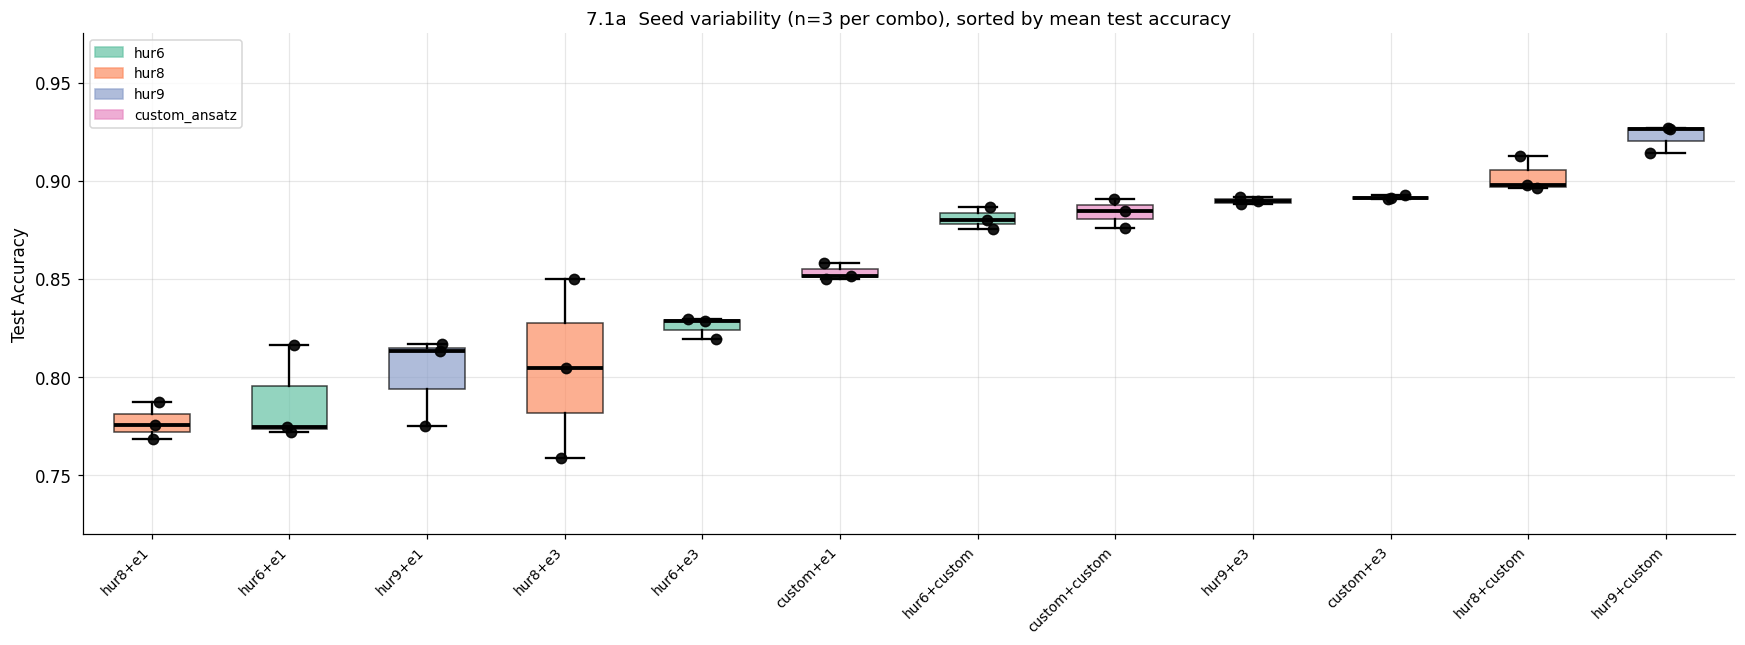

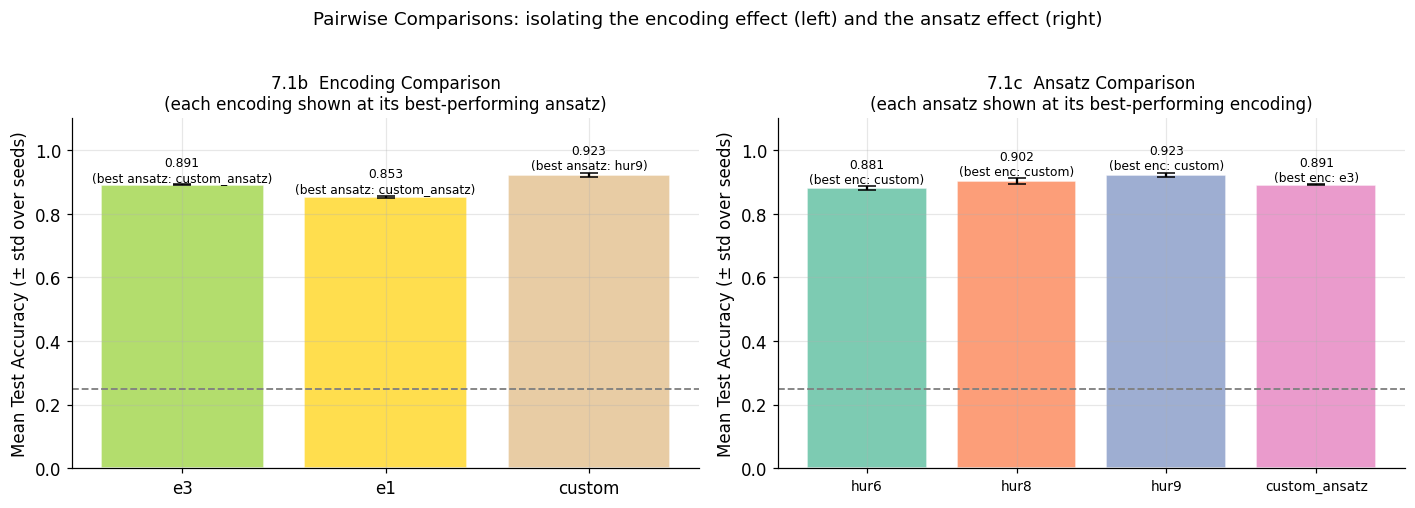

7.1b  Encoding comparison (best ansatz per encoding):
  e3          mean=0.8913  std=0.0010  best_ansatz=custom_ansatz
  e1          mean=0.8532  std=0.0043  best_ansatz=custom_ansatz
  custom      mean=0.9225  std=0.0074  best_ansatz=hur9

7.1c  Ansatz comparison (best encoding per ansatz):
  hur6             mean=0.8807  std=0.0055  best_encoding=custom
  hur8             mean=0.9022  std=0.0090  best_encoding=custom
  hur9             mean=0.9225  std=0.0074  best_encoding=custom
  custom_ansatz    mean=0.8913  std=0.0010  best_encoding=e3


In [13]:
def _no_data(s): print(f"WARNING:  No data for {s}. Ensure results_qcnn/ is populated, then re-run Section 6.")

if df is None:
    _no_data("7.1")
else:
    # Sort combos by mean test accuracy (ascending) so best performers appear rightmost.
    combo_means = df.groupby(["ansatz", "encoding"])["test_acc"].mean()
    combos_sorted = combo_means.sort_values().index.tolist()
    n_c = len(combos_sorted)
    box_data = [df[(df["ansatz"] == a) & (df["encoding"] == e)]["test_acc"].values
                for a, e in combos_sorted]

    # ------------------------------------------------------------------ 7.1a
    fig, ax = plt.subplots(figsize=(16, 6))
    bp = ax.boxplot(box_data, positions=range(n_c), widths=0.55, patch_artist=True,
                    medianprops={"color": "black", "lw": 2.5},
                    whiskerprops={"lw": 1.5}, capprops={"lw": 1.5},
                    flierprops={"marker": "o", "ms": 4})
    for patch, (a, e) in zip(bp["boxes"], combos_sorted):
        patch.set_facecolor(ANSATZ_COLORS.get(a, COLORS[0]))
        patch.set_alpha(0.70)
    np.random.seed(0)
    for i, vals in enumerate(box_data):
        jitter = np.random.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color="black", s=45, zorder=5, alpha=0.90)
    ax.set_xticks(range(n_c))
    ax.set_xticklabels([f"{'custom' if a == 'custom_ansatz' else a}+{e}"
                        for a, e in combos_sorted],
                       rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Test Accuracy", fontsize=11)
    ax.set_ylim(0.72, 0.975)
    ax.set_title("7.1a  Seed variability (n=3 per combo), sorted by mean test accuracy",
                 fontsize=12)
    handles = [mpatches.Patch(color=ANSATZ_COLORS[a], label=a, alpha=0.7)
               for a in ANSATZ_ORDER if a in [c[0] for c in combos_sorted]]
    ax.legend(handles=handles, fontsize=9, loc="upper left")
    plt.tight_layout(); plt.show()

    # ------------------------------------------------------------------ 7.1b/c
    grp_ea = df.groupby(["encoding", "ansatz"])["test_acc"].agg(["mean", "std"]).reset_index()
    grp_ea["std"] = grp_ea["std"].fillna(0)
    grp_ae = df.groupby(["ansatz", "encoding"])["test_acc"].agg(["mean", "std"]).reset_index()
    grp_ae["std"] = grp_ae["std"].fillna(0)

    # Best ansatz per encoding
    enc_best = {}
    for enc in ENC_ORDER:
        sub = grp_ea[grp_ea["encoding"] == enc]
        if not sub.empty:
            enc_best[enc] = sub.loc[sub["mean"].idxmax()]

    # Best encoding per ansatz
    ans_best = {}
    for ans in ANSATZ_ORDER:
        sub = grp_ae[grp_ae["ansatz"] == ans]
        if not sub.empty:
            ans_best[ans] = sub.loc[sub["mean"].idxmax()]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # Left: 7.1b encoding comparison
    if enc_best:
        enc_list = [e for e in ENC_ORDER if e in enc_best]
        m_e = [enc_best[e]["mean"] for e in enc_list]
        s_e = [enc_best[e]["std"]  for e in enc_list]
        b_a = [enc_best[e]["ansatz"] for e in enc_list]
        axes[0].bar(range(len(enc_list)), m_e, yerr=s_e, capsize=6,
                    color=[COLORS[i + 4] for i in range(len(enc_list))],
                    edgecolor="white", alpha=0.85)
        axes[0].axhline(0.25, ls="--", color="gray", lw=1.2)
        axes[0].set_xticks(range(len(enc_list)))
        axes[0].set_xticklabels(enc_list, fontsize=11)
        for i, (m, s, ba) in enumerate(zip(m_e, s_e, b_a)):
            axes[0].text(i, m + s + 0.01,
                         f"{m:.3f}\n(best ansatz: {ba})", ha="center", fontsize=8)
        axes[0].set_ylabel("Mean Test Accuracy (± std over seeds)")
        axes[0].set_ylim(0, 1.1)
        axes[0].set_title("7.1b  Encoding Comparison\n"
                          "(each encoding shown at its best-performing ansatz)", fontsize=11)

    # Right: 7.1c ansatz comparison
    if ans_best:
        ans_list = [a for a in ANSATZ_ORDER if a in ans_best]
        m_a = [ans_best[a]["mean"] for a in ans_list]
        s_a = [ans_best[a]["std"]  for a in ans_list]
        b_e = [ans_best[a]["encoding"] for a in ans_list]
        axes[1].bar(range(len(ans_list)), m_a, yerr=s_a, capsize=6,
                    color=[ANSATZ_COLORS.get(a, COLORS[0]) for a in ans_list],
                    edgecolor="white", alpha=0.85)
        axes[1].axhline(0.25, ls="--", color="gray", lw=1.2)
        axes[1].set_xticks(range(len(ans_list)))
        axes[1].set_xticklabels(ans_list, fontsize=9)
        for i, (m, s, be) in enumerate(zip(m_a, s_a, b_e)):
            axes[1].text(i, m + s + 0.01,
                         f"{m:.3f}\n(best enc: {be})", ha="center", fontsize=8)
        axes[1].set_ylabel("Mean Test Accuracy (± std over seeds)")
        axes[1].set_ylim(0, 1.1)
        axes[1].set_title("7.1c  Ansatz Comparison\n"
                          "(each ansatz shown at its best-performing encoding)", fontsize=11)

    fig.suptitle("Pairwise Comparisons: isolating the encoding effect (left) "
                 "and the ansatz effect (right)", fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()

    print("7.1b  Encoding comparison (best ansatz per encoding):")
    for enc in [e for e in ENC_ORDER if e in enc_best]:
        r = enc_best[enc]
        print(f"  {enc:10s}  mean={r['mean']:.4f}  std={r['std']:.4f}"
              f"  best_ansatz={r['ansatz']}")
    print()
    print("7.1c  Ansatz comparison (best encoding per ansatz):")
    for ans in [a for a in ANSATZ_ORDER if a in ans_best]:
        r = ans_best[ans]
        print(f"  {ans:15s}  mean={r['mean']:.4f}  std={r['std']:.4f}"
              f"  best_encoding={r['encoding']}")

### 7.2 Ansatz × Encoding Heatmap

Darker = higher mean test accuracy. Cells without results appear masked.

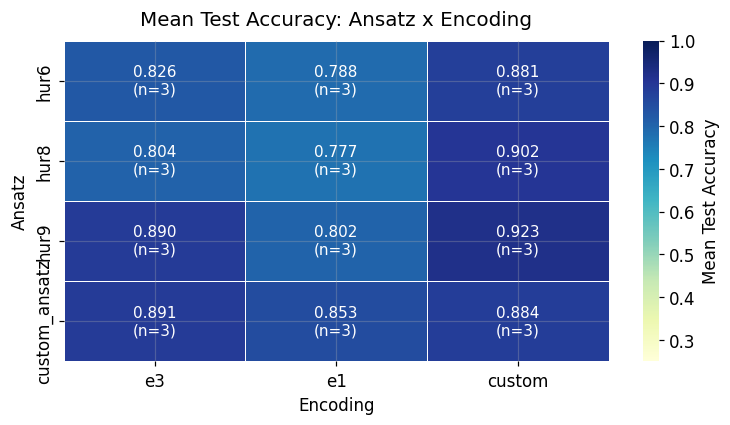

In [14]:
if df is None:
    _no_data("7.2")
else:
    grp2 = df.groupby(["ansatz","encoding"])["test_acc"].mean().reset_index()
    pivot2 = grp2.pivot(index="ansatz", columns="encoding", values="test_acc")
    pa = [a for a in ANSATZ_ORDER if a in pivot2.index]
    pe = [e for e in ENC_ORDER if e in pivot2.columns]
    pivot2 = pivot2.reindex(index=pa, columns=pe)

    cnt = df.groupby(["ansatz","encoding"])["seed"].count().reset_index()
    cnt = cnt.pivot(index="ansatz", columns="encoding", values="seed").reindex(index=pa, columns=pe)

    annot = pivot2.copy().astype(object)
    for i in pa:
        for j in pe:
            v = pivot2.loc[i, j]; n = int(cnt.loc[i, j]) if not pd.isna(cnt.loc[i, j]) else 0
            annot.loc[i, j] = f"{v:.3f}\n(n={n})" if not pd.isna(v) else "-"

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(pivot2, annot=annot, fmt="", cmap="YlGnBu", vmin=0.25, vmax=1.0,
                linewidths=0.5, ax=ax, mask=pivot2.isna(),
                cbar_kws={"label": "Mean Test Accuracy"}, annot_kws={"size": 10})
    ax.set_title("Mean Test Accuracy: Ansatz x Encoding", fontsize=13, pad=10)
    ax.set_xlabel("Encoding"); ax.set_ylabel("Ansatz")
    plt.tight_layout(); plt.show()

### 7.3 Training Dynamics

For each combination: **train accuracy** (solid line) and **validation accuracy** (dashed
line), mean ± std over seeds. A large train-val gap indicates overfitting; slow convergence
with val_acc closely tracking train_acc suggests underfitting or a difficult loss landscape.

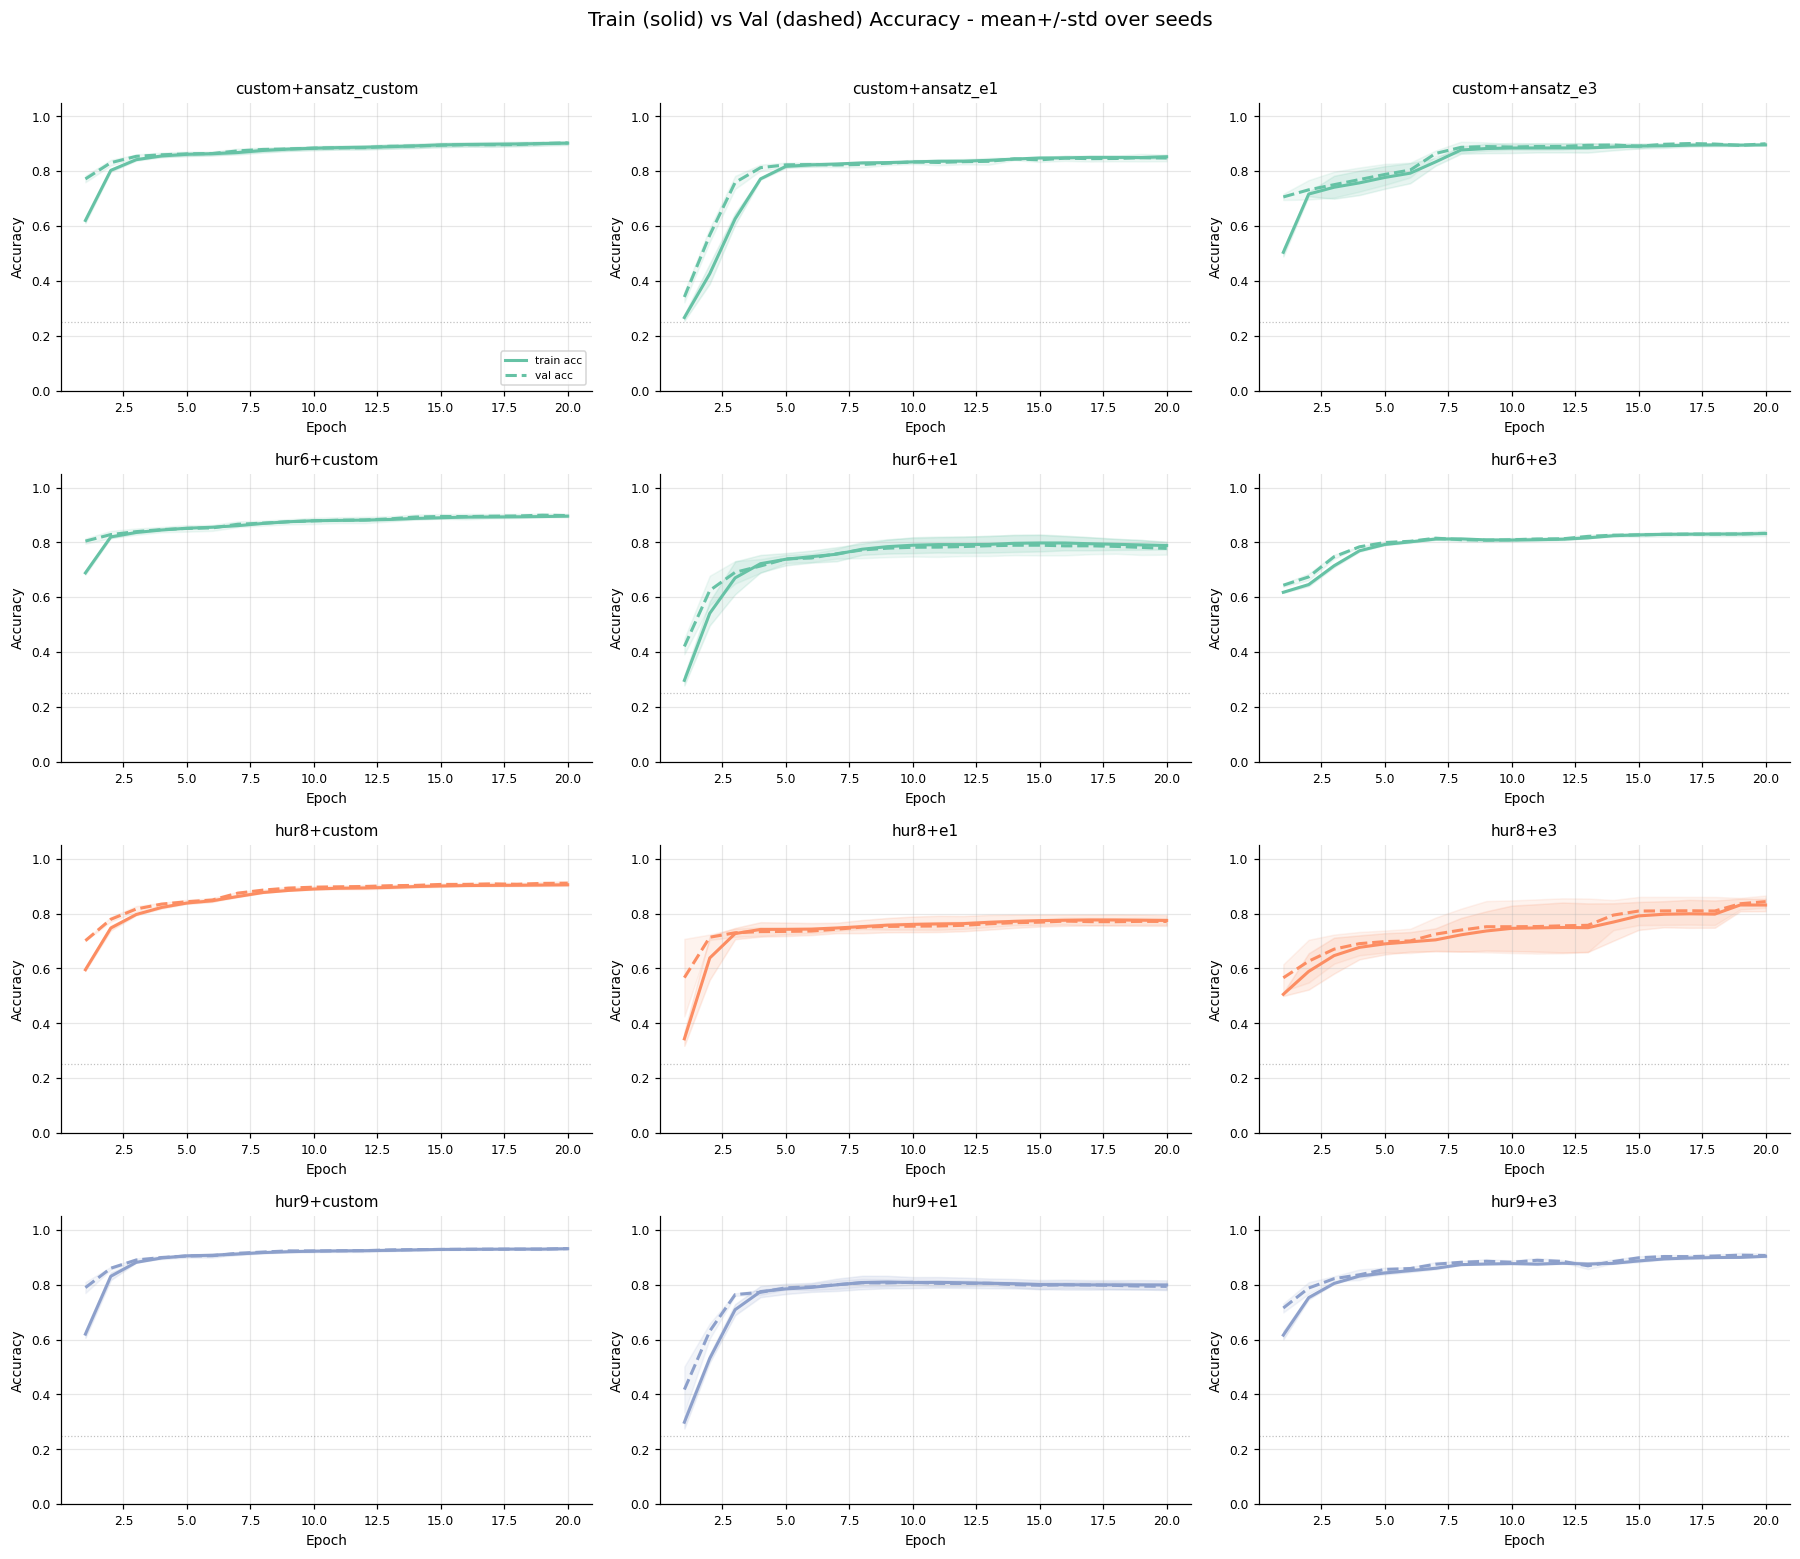

In [15]:
if not curves:
    _no_data("7.3 - no metrics.csv files found")
else:
    keys = sorted(curves.keys())
    ncols = min(3, len(keys))
    nrows = (len(keys) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 3.5*nrows), squeeze=False)
    axf = axes.flatten()

    for idx, key in enumerate(keys):
        ax = axf[idx]
        seed_dfs = curves[key]
        max_ep = max(c["epoch"].max() for c in seed_dfs)
        train_mat = np.full((len(seed_dfs), int(max_ep)), np.nan)
        val_mat   = np.full((len(seed_dfs), int(max_ep)), np.nan)
        for si, c in enumerate(seed_dfs):
            ep = c["epoch"].astype(int).values - 1
            for e, ta, va in zip(ep, c["train_acc"].values, c["val_acc"].values):
                if 0 <= e < int(max_ep):
                    train_mat[si, e] = ta
                    val_mat[si, e]   = va

        x = np.arange(1, int(max_ep)+1)
        ans_part = key.split("_")[0]
        color = ANSATZ_COLORS.get(ans_part, COLORS[0])

        m_tr, s_tr = np.nanmean(train_mat, 0), np.nanstd(train_mat, 0)
        m_va, s_va = np.nanmean(val_mat,   0), np.nanstd(val_mat,   0)

        ax.plot(x, m_tr, color=color, lw=2, label="train acc")
        ax.fill_between(x, m_tr-s_tr, m_tr+s_tr, alpha=0.15, color=color)
        ax.plot(x, m_va, color=color, lw=2, ls="--", label="val acc")
        ax.fill_between(x, m_va-s_va, m_va+s_va, alpha=0.10, color=color)
        ax.axhline(0.25, ls=":", color="gray", lw=0.8, alpha=0.5)
        ax.set_title(key.replace("_", "+", 1), fontsize=10)
        ax.set_xlabel("Epoch", fontsize=9); ax.set_ylabel("Accuracy", fontsize=9)
        ax.set_ylim(0, 1.05); ax.tick_params(labelsize=8)
        if idx == 0:
            ax.legend(fontsize=7, loc="lower right")

    for ax in axf[len(keys):]: ax.set_visible(False)
    fig.suptitle("Train (solid) vs Val (dashed) Accuracy - mean+/-std over seeds", fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

### 7.4 Confusion Matrices

One matrix per (ansatz, encoding) combination, **summed over the three seeds**.
Cell values show absolute counts; cell colour encodes the row-normalised fraction
(recall per class).

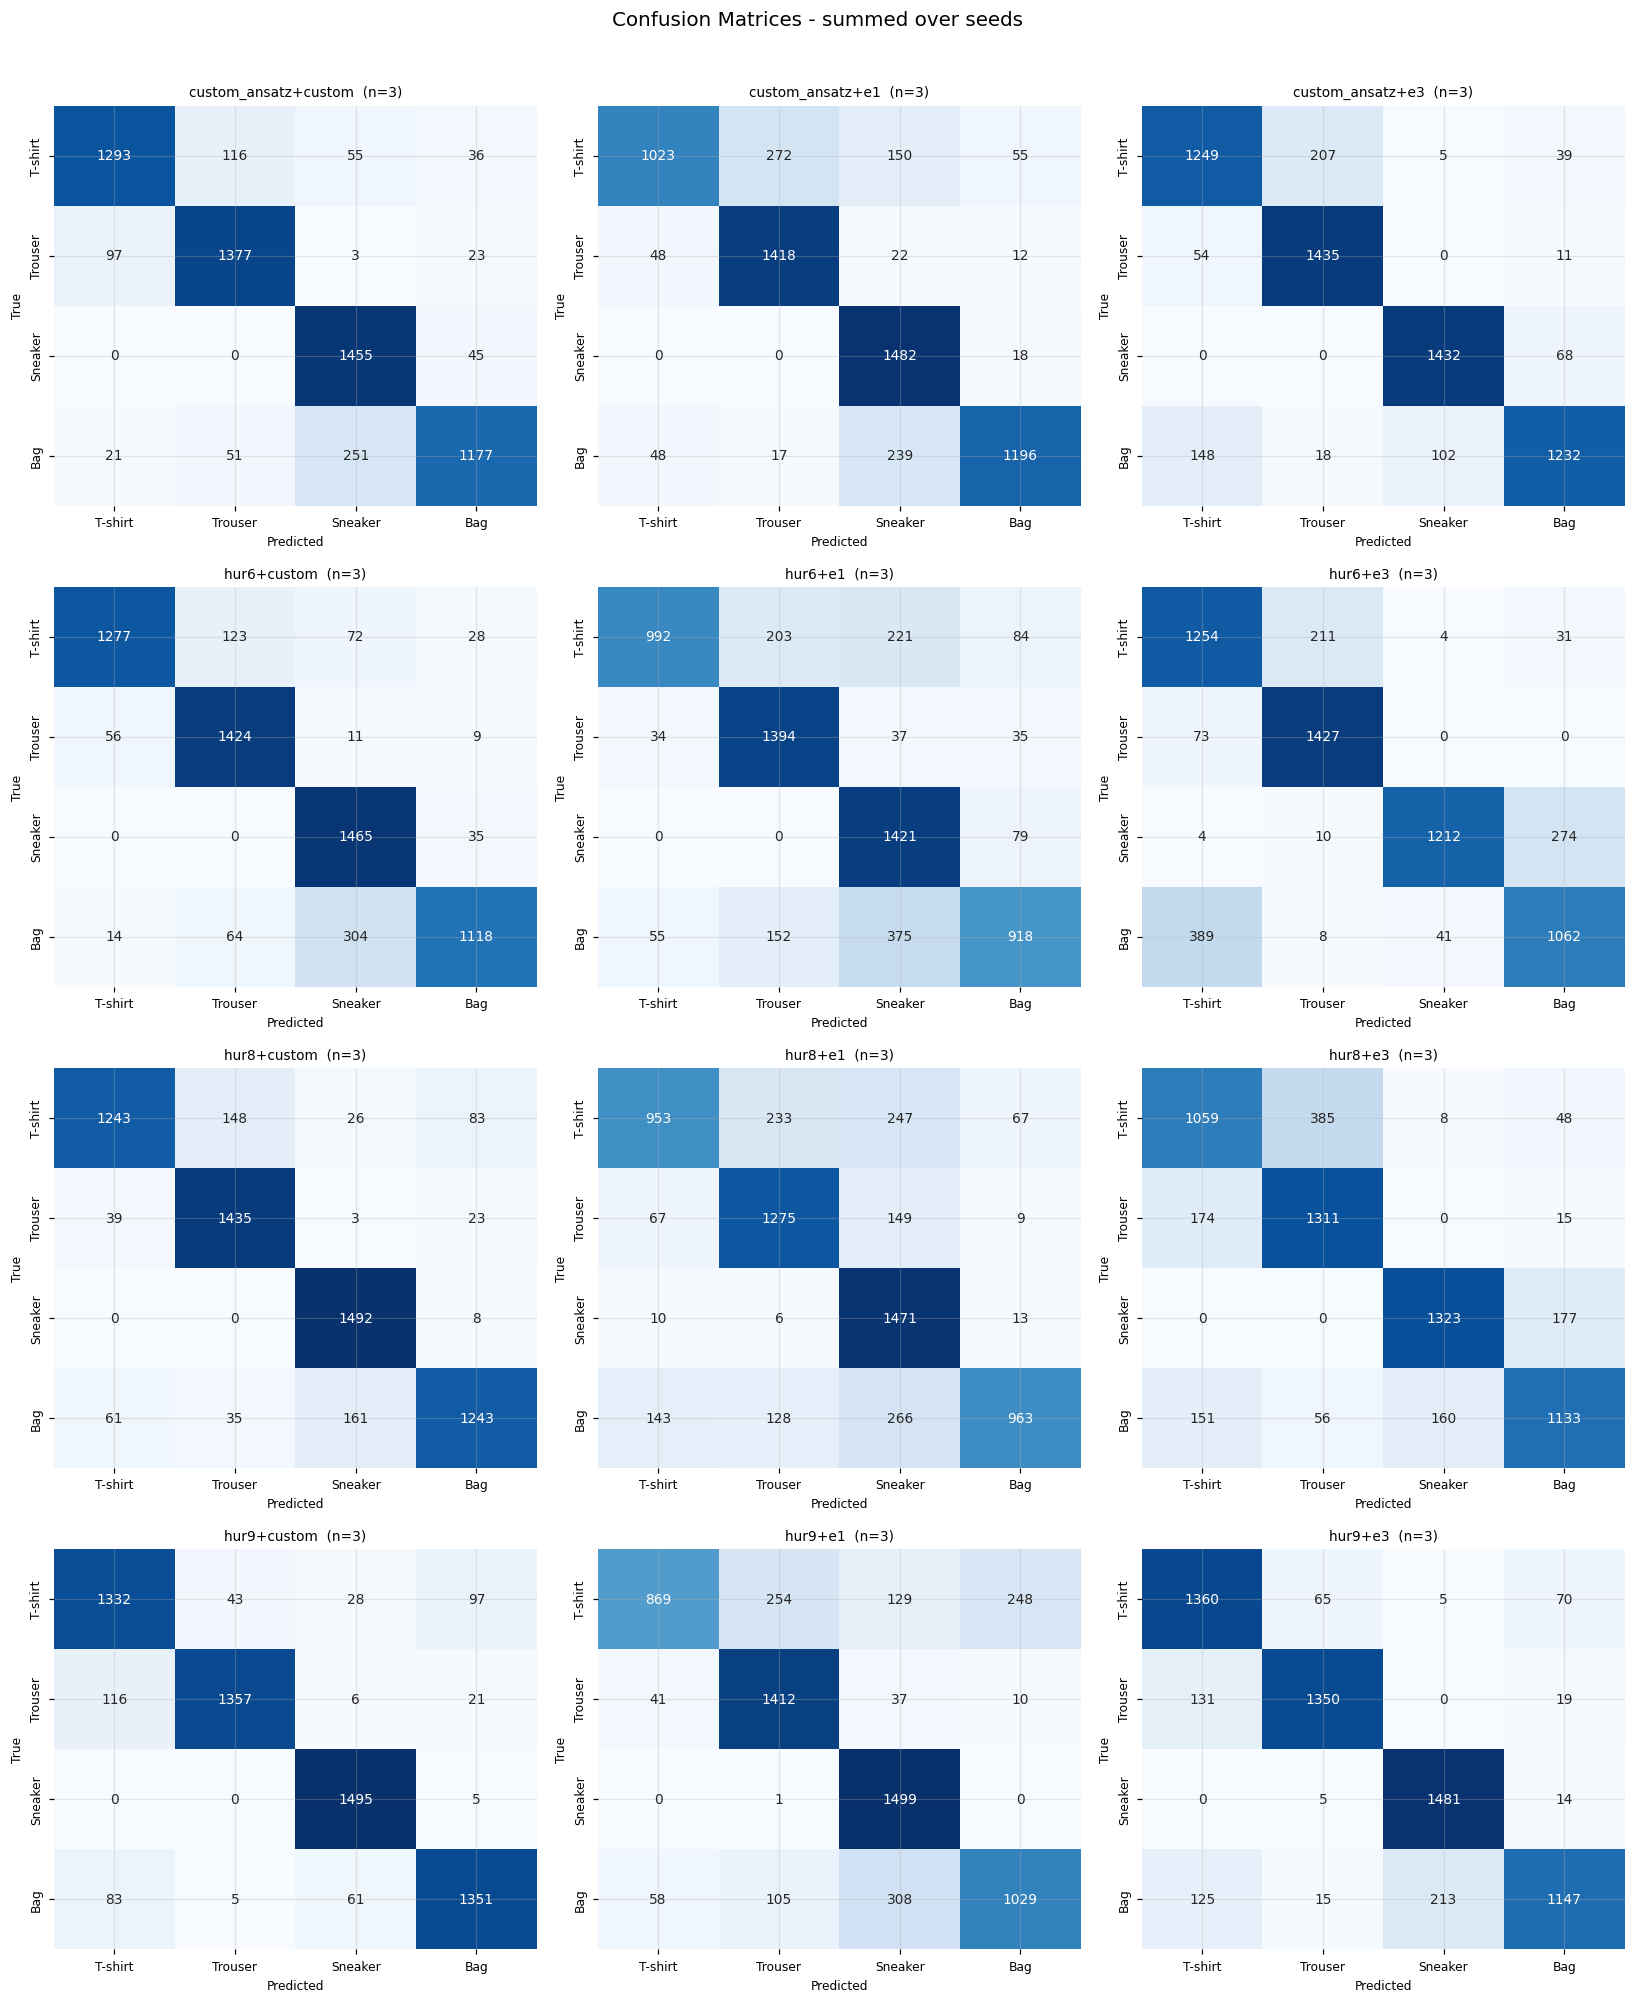

In [16]:
def _extract_cm(row, n=4):
    cm = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(n):
            col = f"cm_{i}{j}"
            if col in row.index and not pd.isna(row[col]):
                cm[i, j] = int(row[col])
    return cm

def _plot_cm(ax, cm, title):
    norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(norm, annot=cm, fmt="d", cmap="Blues", vmin=0, vmax=1,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False, annot_kws={"size": 9})
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Predicted", fontsize=8); ax.set_ylabel("True", fontsize=8)
    ax.tick_params(labelsize=8)

if df is None:
    _no_data("7.4")
else:
    combos = sorted(df.groupby(["ansatz","encoding"]).groups.keys())
    ncols = min(3, len(combos))
    nrows = (len(combos) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows), squeeze=False)
    axf = axes.flatten()
    for idx, (ans, enc) in enumerate(combos):
        sub = df[(df["ansatz"]==ans) & (df["encoding"]==enc)]
        cm_tot = sum(_extract_cm(r) for _, r in sub.iterrows())
        _plot_cm(axf[idx], cm_tot, f"{ans}+{enc}  (n={len(sub)})")
    for ax in axf[len(combos):]: ax.set_visible(False)
    fig.suptitle("Confusion Matrices - summed over seeds", fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

### 7.5 Per-class Accuracy

Per-class accuracy extracted from the confusion-matrix diagonal. Reveals which classes are
systematically harder to distinguish and whether particular configurations improve the
decision boundary for specific class pairs.

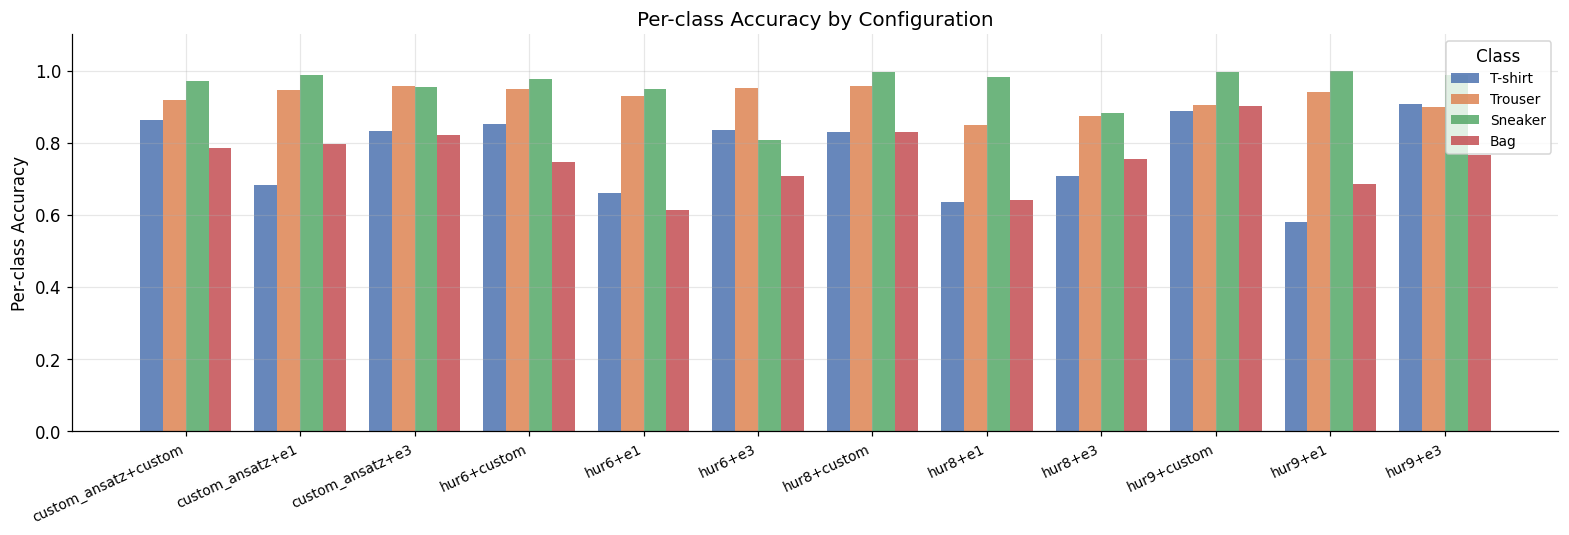


Per-class accuracy table:


'               combo  T-shirt  Trouser  Sneaker   Bag\ncustom_ansatz+custom    0.862    0.918    0.970 0.785\n    custom_ansatz+e1    0.682    0.945    0.988 0.797\n    custom_ansatz+e3    0.833    0.957    0.955 0.821\n         hur6+custom    0.851    0.949    0.977 0.745\n             hur6+e1    0.661    0.929    0.947 0.612\n             hur6+e3    0.836    0.951    0.808 0.708\n         hur8+custom    0.829    0.957    0.995 0.829\n             hur8+e1    0.635    0.850    0.981 0.642\n             hur8+e3    0.706    0.874    0.882 0.755\n         hur9+custom    0.888    0.905    0.997 0.901\n             hur9+e1    0.579    0.941    0.999 0.686\n             hur9+e3    0.907    0.900    0.987 0.765'

In [17]:
if df is None:
    _no_data("7.5")
else:
    rows = []
    for ans, enc in sorted(df.groupby(["ansatz","encoding"]).groups.keys()):
        sub = df[(df["ansatz"]==ans) & (df["encoding"]==enc)]
        cm = sum(_extract_cm(r) for _, r in sub.iterrows())
        acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
        rows.append({"combo": f"{ans}+{enc}", **{CLASS_NAMES[k]: acc[k] for k in range(4)}})
    df_pc = pd.DataFrame(rows)

    x = np.arange(len(df_pc)); w = 0.2
    cls_colors = ["#4C72B0","#DD8452","#55A868","#C44E52"]
    fig, ax = plt.subplots(figsize=(max(10, len(df_pc)*1.2), 5))
    for k, cn in enumerate(CLASS_NAMES):
        ax.bar(x + k*w, df_pc[cn], w, label=cn, color=cls_colors[k], alpha=0.85)
    ax.set_xticks(x + 1.5*w)
    ax.set_xticklabels(df_pc["combo"], rotation=25, ha="right", fontsize=9)
    ax.set_ylabel("Per-class Accuracy"); ax.set_ylim(0, 1.1)
    ax.set_title("Per-class Accuracy by Configuration", fontsize=13)
    ax.legend(title="Class", fontsize=9)
    plt.tight_layout(); plt.show()
    print("\nPer-class accuracy table:")
    display(df_pc.round(3).to_string(index=False))

### 7.6 Parameter Efficiency

Scatter of mean test accuracy vs. total trainable parameters. The top-left region represents
the most parameter-efficient configurations (high accuracy, low parameter count). Error bars
show ± std over seeds; marker shape encodes the encoding strategy; colour encodes the ansatz.

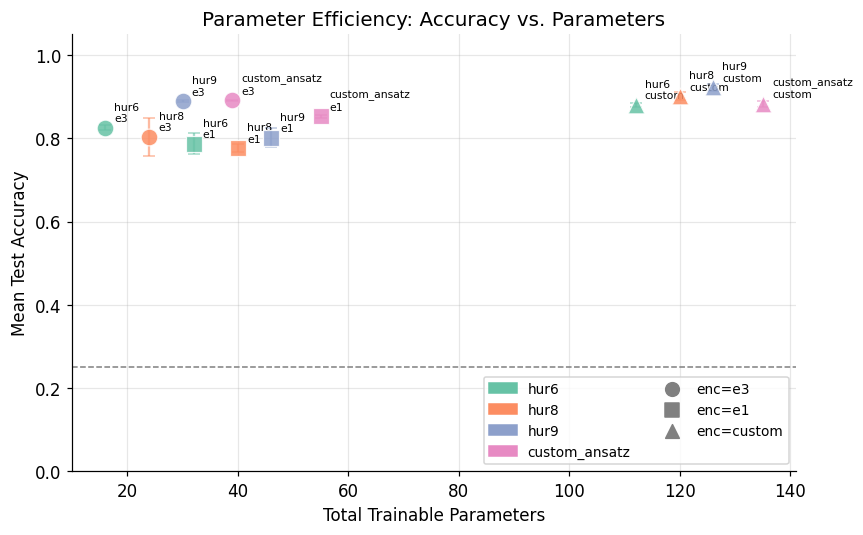

In [18]:
if df is None:
    _no_data("7.6")
else:
    grp_pe = df.groupby(["ansatz","encoding"]).agg(
        mean_acc=("test_acc","mean"), std_acc=("test_acc","std"),
        n_params=("n_params","first")).reset_index()
    enc_markers = {"e3":"o","e1":"s","custom":"^"}

    fig, ax = plt.subplots(figsize=(8, 5))
    for _, r in grp_pe.iterrows():
        m = enc_markers.get(r["encoding"], "D")
        c = ANSATZ_COLORS.get(r["ansatz"], COLORS[0])
        ax.scatter(r["n_params"], r["mean_acc"], s=120, marker=m, color=c,
                   alpha=0.85, zorder=3, edgecolors="white", lw=0.8)
        ax.errorbar(r["n_params"], r["mean_acc"],
                    yerr=r["std_acc"] if not pd.isna(r["std_acc"]) else 0,
                    fmt="none", color=c, capsize=4, lw=1.5, alpha=0.6)
        ax.annotate(f'{r["ansatz"]}\n{r["encoding"]}',
                    (r["n_params"], r["mean_acc"]),
                    textcoords="offset points", xytext=(6,4), fontsize=7)
    ax.axhline(0.25, ls="--", color="gray", lw=1, label="Random chance")
    ax.set_xlabel("Total Trainable Parameters"); ax.set_ylabel("Mean Test Accuracy")
    ax.set_ylim(0, 1.05)
    ax.set_title("Parameter Efficiency: Accuracy vs. Parameters", fontsize=13)
    ans_h = [mpatches.Patch(color=ANSATZ_COLORS[a], label=a)
             for a in ANSATZ_ORDER if a in grp_pe["ansatz"].values]
    enc_h = [plt.scatter([],[], marker=enc_markers[e], color="gray", s=80, label=f"enc={e}")
             for e in ENC_ORDER if e in grp_pe["encoding"].values]
    ax.legend(handles=ans_h+enc_h, fontsize=9, loc="lower right", ncol=2)
    plt.tight_layout(); plt.show()

### 7.7 Circuit Complexity: Raw vs. Transpiled Gate Count

CNOT counts broken down by encoding block vs. QCNN backbone. `e3` (AmplitudeEmbedding) dominates with ~254 CNOTs regardless of ansatz. If Qiskit is installed, also shows transpiled 2Q-gate counts for a 127-qubit IBM backend.

INFO: Qiskit not installed. Showing raw CX counts only.
      Uncomment the %pip install line above to enable transpiled counts.


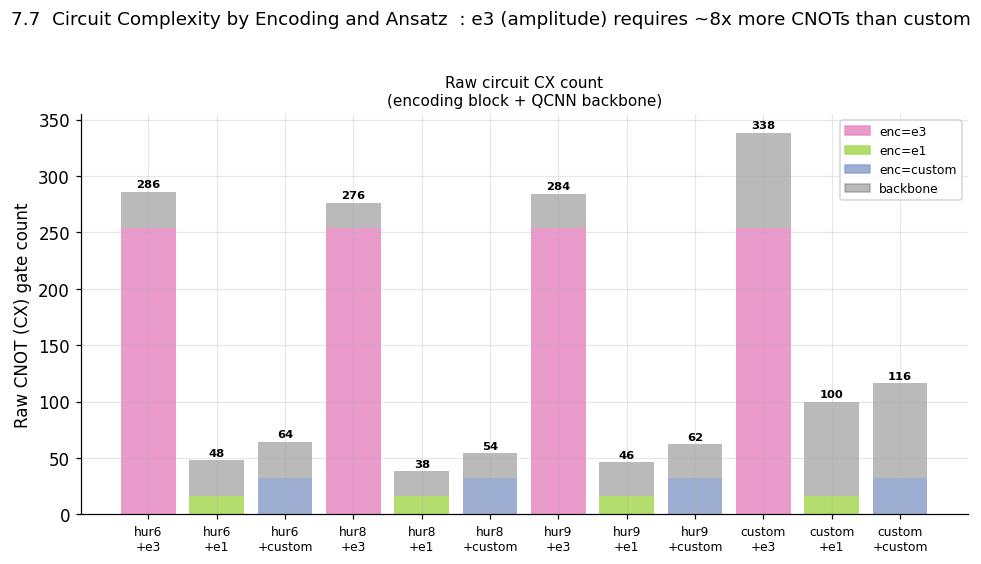


Raw CX breakdown:
Combo                              Enc CX   Backbone   Total
  hur6+e3                             254         32     286
  hur6+e1                              16         32      48
  hur6+custom                          32         32      64
  hur8+e3                             254         22     276
  hur8+e1                              16         22      38
  hur8+custom                          32         22      54
  hur9+e3                             254         30     284
  hur9+e1                              16         30      46
  hur9+custom                          32         30      62
  custom_a+e3                         254         84     338
  custom_a+e1                          16         84     100
  custom_a+custom                      32         84     116


In [19]:
# %pip install -q qiskit qiskit-ibm-runtime   # uncomment if not installed

import math as _math

# ============================================================
# Raw CX counts (analytical, exact from gate definitions)
# ============================================================
# Encoding block, independent of ansatz:
#   e3: AmplitudeEmbedding via Qiskit initialize: 2^8 - 2 ≈ 254 CNOTs
#   e1: 8 qubits × CNOT-RZ-CNOT fusion = 8 × 2 = 16 CNOTs
#   custom: 4 pairs × 4 upload steps × 2 CX = 32 CNOTs
ENC_CX = {"e3": 254, "e1": 16, "custom": 32}

# Backbone, depends only on ansatz (conv1 + pool1 + conv2 + pool2 [+ final]):
#   hur6 (2 CX/pair):  7×2 + 4×2 + 3×2 + 2×2            = 32
#   hur8 (1 CX/pair):  7×1 + 4×2 + 3×1 + 2×2            = 22
#   hur9 (3 CX/pair, trace-out pool): 7×3 + 3×3          = 30
#   custom_ansatz (Ising = 6 CX/pair, transfer pool 3 CX, +final 6 CX):
#       7×6 + 4×3 + 3×6 + 2×3 + 1×6                     = 84
BACKBONE_CX = {"hur6": 32, "hur8": 22, "hur9": 30, "custom_ansatz": 84}

circ_rows = []
for ans in ANSATZ_ORDER:
    for enc in ENC_ORDER:
        ec = ENC_CX[enc]; bc = BACKBONE_CX[ans]
        circ_rows.append({"ansatz": ans, "encoding": enc,
                          "enc_cx": ec, "backbone_cx": bc, "total_cx": ec + bc})
df_circ = pd.DataFrame(circ_rows)

# ============================================================
# Optional Qiskit transpilation
# ============================================================
df_transpiled = None
transpile_backend_name = None

try:
    from qiskit import QuantumCircuit, ClassicalRegister
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    def _u3(qc, t, p, l, q):
        qc.u(t, p, l, q) if hasattr(qc, "u") else qc.u3(t, p, l, q)

    def _hur6_q(qc, th, a, b):
        qc.ry(th[0],a); qc.ry(th[1],b); qc.cx(a,b)
        qc.ry(th[2],a); qc.ry(th[3],b); qc.cx(a,b); qc.ry(th[4],a); qc.ry(th[5],b)
    def _hur8_q(qc, th, a, b):
        qc.rx(th[0],a); qc.rx(th[1],b); qc.rz(th[2],a); qc.rz(th[3],b)
        qc.rx(th[4],a); qc.rx(th[5],b); qc.cx(a,b)
        qc.rx(th[6],a); qc.rx(th[7],b); qc.rz(th[8],a); qc.rz(th[9],b)
    def _hur9_q(qc, th, a, b):
        _u3(qc,th[0],th[1],th[2],a); _u3(qc,th[3],th[4],th[5],b)
        qc.cx(a,b); qc.ry(th[6],a); qc.rz(th[7],b)
        qc.cx(b,a); qc.ry(th[8],a); qc.cx(a,b)
        _u3(qc,th[9],th[10],th[11],a); _u3(qc,th[12],th[13],th[14],b)
    def _cartan_q(qc, th, a, b):
        qc.rz(th[0],a); qc.ry(th[1],a); qc.rz(th[2],b); qc.ry(th[3],b)
        qc.rxx(th[4],a,b); qc.ryy(th[5],a,b); qc.rzz(th[6],a,b)
        qc.ry(th[7],a); qc.rz(th[8],a); qc.ry(th[9],b); qc.rz(th[10],b)
    def _hur_pool_q(qc, th, c, t):
        qc.crz(th[0],c,t); qc.x(c); qc.crx(th[1],c,t); qc.x(c)
    def _transfer_pool_q(qc, th, d, k):
        qc.cx(d,k); qc.cry(th[0],d,k); qc.crz(th[1],d,k); qc.ry(th[2],k)

    QISKIT_CONV = {"hur6": (_hur6_q, 6), "hur8": (_hur8_q, 10),
                   "hur9": (_hur9_q, 15), "custom_ansatz": (_cartan_q, 11)}
    QISKIT_POOL = {"hur6": (_hur_pool_q, 2), "hur8": (_hur_pool_q, 2),
                   "hur9": (_hur_pool_q, 2), "custom_ansatz": (_transfer_pool_q, 3)}

    def _conv_layer_q(fn, qc, th, wires):
        n = len(wires)
        for a, b in ([(wires[i],wires[i+1]) for i in range(0,n-1,2)] +
                     [(wires[i],wires[i+1]) for i in range(1,n-1,2)]):
            fn(qc, th, a, b)

    def _build_circuit(ans_name, enc_name):
        n_q = 9 if enc_name == "e1" else 8
        qc = QuantumCircuit(n_q)
        rng = np.random.default_rng(0)
        # Encoding
        if enc_name == "e3":
            x = rng.random(256); x /= np.linalg.norm(x)
            qc.initialize(x, list(range(8)))
        elif enc_name == "e1":
            for i in range(8): qc.ry(0.5, i)
            for g in [qc.ry, qc.rz, qc.rx, qc.rz, qc.ry, qc.rz, qc.rx, qc.ry, qc.rz]:
                g(0.1, 8)
            for i in range(8): qc.cx(8,i); qc.rz(_math.pi/4,i); qc.cx(8,i)
        else:  # custom
            for a, b in [(0,1),(2,3),(4,5),(6,7)]:
                for _ in range(4):
                    for g, q in [(qc.ry,a),(qc.rz,a),(qc.rx,b),(qc.ry,b)]: g(0.1,q)
                    qc.cx(a,b); qc.ry(0.1,a); qc.rz(0.1,b)
                    qc.cx(b,a); qc.rx(0.1,a); qc.ry(0.1,b)
        # QCNN backbone
        conv_fn, nc = QISKIT_CONV[ans_name]
        pool_fn, np_ = QISKIT_POOL[ans_name]
        # Non-zero random params: zeros collapse Ising gates to identity (wrong transpiled counts).
        _prng = np.random.default_rng(42 + sum((i+1)*ord(c) for i,c in enumerate(ans_name+enc_name)))
        th_c = _prng.uniform(-_math.pi, _math.pi, nc)
        th_p = _prng.uniform(-_math.pi, _math.pi, np_)
        use_pool  = ans_name != "hur9"
        use_final = ans_name == "custom_ansatz"
        pool_layer_fn = _transfer_pool_q if use_final else _hur_pool_q
        _conv_layer_q(conv_fn, qc, th_c, [0,1,2,3,4,5,6,7])
        if use_pool:
            for c, t in [(1,0),(3,2),(5,4),(7,6)]: pool_layer_fn(qc, th_p, c, t)
        _conv_layer_q(conv_fn, qc, th_c, [0,2,4,6])
        if use_pool:
            for c, t in [(2,0),(6,4)]: pool_layer_fn(qc, th_p, c, t)
        if use_final: conv_fn(qc, th_c, 0, 4)
        cr = ClassicalRegister(2); qc.add_register(cr)
        qc.measure(0, cr[0]); qc.measure(4, cr[1])
        return qc

    def _count_2q(qc):
        return sum(1 for i in qc.data if i.operation.num_qubits == 2)
    def _depth_2q_q(qc):
        try: return qc.depth(filter_function=lambda i: i.operation.num_qubits == 2)
        except TypeError: return qc.depth(filter_function=lambda i: i[0].num_qubits == 2)

    backend = None
    for mod_name, cls_name in [("qiskit_ibm_runtime.fake_provider","FakeSherbrooke"),
                                ("qiskit.providers.fake_provider","FakeSherbrooke"),
                                ("qiskit_ibm_runtime.fake_provider","FakeTorino")]:
        try:
            m = __import__(mod_name, fromlist=[cls_name])
            backend = getattr(m, cls_name)(); transpile_backend_name = cls_name; break
        except Exception: pass

    if backend is not None:
        pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
        tr_rows = []
        for _, row in df_circ.iterrows():
            try:
                qc_raw = _build_circuit(row["ansatz"], row["encoding"])
                qc_tr  = pm.run(qc_raw)
                tr_rows.append({"ansatz": row["ansatz"], "encoding": row["encoding"],
                                 "raw_cx": row["total_cx"], "tr_2q": _count_2q(qc_tr),
                                 "tr_depth": _depth_2q_q(qc_tr), "tr_size": qc_tr.size()})
            except Exception as e:
                print(f"  WARNING: {row['ansatz']}+{row['encoding']}: {e}")
        if tr_rows:
            df_transpiled = pd.DataFrame(tr_rows)
            print(f"[OK] Transpilation complete  backend={transpile_backend_name}, opt_level=3")
    else:
        print("INFO: No Qiskit fake backend available. Showing raw CX counts only.")
        print("      pip install qiskit qiskit-ibm-runtime, then re-run.")
except ImportError:
    print("INFO: Qiskit not installed. Showing raw CX counts only.")
    print("      Uncomment the %pip install line above to enable transpiled counts.")

# ============================================================
# Visualization
# ============================================================
ENC_CIRC_COLORS = {"e3": COLORS[3], "e1": COLORS[4], "custom": COLORS[2]}
BACKBONE_COLOR  = "#777777"
combos_ord = [(a, e) for a in ANSATZ_ORDER for e in ENC_ORDER]
labels_c   = [f"{a.replace('_ansatz','')}\n+{e}" for a, e in combos_ord]
enc_vals   = [ENC_CX[e]      for a, e in combos_ord]
back_vals  = [BACKBONE_CX[a] for a, e in combos_ord]
x_c = np.arange(len(combos_ord))

ncols = 2 if df_transpiled is not None else 1
fig, axes = plt.subplots(1, ncols, figsize=(15 if ncols == 2 else 9, 5))
if ncols == 1: axes = [axes]

# --- Left: stacked raw CX (always) ------------------------------------------
ax0 = axes[0]
bars_e = ax0.bar(x_c, enc_vals,  color=[ENC_CIRC_COLORS[e] for _,e in combos_ord], alpha=0.85)
bars_b = ax0.bar(x_c, back_vals, bottom=enc_vals, color=BACKBONE_COLOR, alpha=0.5)
ax0.set_xticks(x_c); ax0.set_xticklabels(labels_c, fontsize=8)
ax0.set_ylabel("Raw CNOT (CX) gate count")
ax0.set_title("Raw circuit CX count\n(encoding block + QCNN backbone)", fontsize=10)
enc_h = [mpatches.Patch(color=ENC_CIRC_COLORS[e], label=f"enc={e}", alpha=0.85) for e in ENC_ORDER]
ax0.legend(handles=enc_h + [mpatches.Patch(color=BACKBONE_COLOR, label="backbone", alpha=0.5)], fontsize=8)
for i, (ev, bv) in enumerate(zip(enc_vals, back_vals)):
    ax0.text(i, ev + bv + 4, str(ev + bv), ha="center", fontsize=7.5, fontweight="bold")

# --- Right: raw vs transpiled (optional) ------------------------------------
if df_transpiled is not None:
    ax1 = axes[1]
    w = 0.35
    for i, (ans, enc) in enumerate(combos_ord):
        row_t = df_transpiled[(df_transpiled["ansatz"]==ans) & (df_transpiled["encoding"]==enc)]
        if row_t.empty: continue
        rv = enc_vals[i] + back_vals[i]; tv = int(row_t["tr_2q"].iloc[0])
        c = ENC_CIRC_COLORS[enc]
        ax1.bar(i - w/2, rv, w, color=c, alpha=0.45)
        ax1.bar(i + w/2, tv, w, color=c, alpha=0.9)
        ax1.text(i - w/2, rv + 8, str(rv), ha="center", fontsize=6.5)
        ax1.text(i + w/2, tv + 8, str(tv), ha="center", fontsize=6.5, fontweight="bold")
    ax1.set_xticks(x_c); ax1.set_xticklabels(labels_c, fontsize=8)
    ax1.set_ylabel("2-qubit gate count")
    ax1.set_title(f"Raw (light) vs transpiled (dark) 2Q gates\n{transpile_backend_name}, opt_level=3", fontsize=10)
    ax1.legend(handles=[mpatches.Patch(color=ENC_CIRC_COLORS[e], alpha=0.45, label=f"raw enc={e}") for e in ENC_ORDER] +
                       [mpatches.Patch(color=ENC_CIRC_COLORS[e], alpha=0.9, label=f"transpiled enc={e}") for e in ENC_ORDER],
               fontsize=7, ncol=2)

fig.suptitle("7.7  Circuit Complexity by Encoding and Ansatz  "
             ": e3 (amplitude) requires ~8x more CNOTs than custom", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

print("\nRaw CX breakdown:")
print(f"{'Combo':<32} {'Enc CX':>8} {'Backbone':>10} {'Total':>7}")
for ans, enc in combos_ord:
    ec = ENC_CX[enc]; bc = BACKBONE_CX[ans]
    print(f"  {ans.replace('_ansatz','_a')+'+'+ enc:<30} {ec:>8} {bc:>10} {ec+bc:>7}")
if df_transpiled is not None:
    print(f"\nTranspiled ({transpile_backend_name}) 2Q gate count:")
    display(df_transpiled[["ansatz","encoding","raw_cx","tr_2q","tr_depth","tr_size"]].to_string(index=False))